# 🦷 DoubleU-Net — Dental Caries Segmentation on DC1000 (single-notebook port)

Faithful one-notebook reproduction of the official repo
[`JunZengz/dental-caries-segmentation`](https://github.com/JunZengz/dental-caries-segmentation)
for the paper **"When CNNs Outperform Transformers and Mambas"** (arXiv:2511.14860), which
reports **DoubleU-Net as the best model on DC1000** (mDSC 0.7345, mIoU 0.5978, Precision 0.8145).

**This notebook keeps the repo's training recipe identical** and just bundles
download → train → curves → evaluate → inference into one runnable file so you can upload a
single notebook to a rented GPU and run it top-to-bottom.

| Setting | Value (exact, from the repo) |
|---|---|
| Model | DoubleU-Net (VGG19 encoder1 + ASPP + dual decoder, SE blocks) |
| Loss | DiceFocalLoss(α=0.75, γ=2.0, dice=0.5, focal=0.5), deep supervision `loss(y1)+loss(y2)` |
| Input | 384×384, 3-channel RGB, `/255` |
| Aug (train) | HFlip(0.5), ShiftScaleRotate(0.05,0.05,15°,p=0.3), RandomBrightnessContrast(p=0.3) |
| Optimizer | Adam, lr=1e-4 |
| Scheduler | ReduceLROnPlateau(min, patience=5) on val loss |
| Epochs | 500, early stopping patience=50 |
| Best model | selected on **highest validation F1 (=Dice)** |

**Added (logging/outputs only):** tqdm+ETA, per-epoch CSV, learning curves, `best.pth`,
full test metrics, and saved prediction maps. Everything is written under `output_caries/`.

## 1. Environment

In [1]:
!nvidia-smi

Tue Jun 30 02:52:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:01:00.0 Off |                  Off |
| 31%   43C    P8             12W /  450W |       1MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
# DoubleU-Net needs only torch + torchvision (VGG19) + albumentations + the usual stack.
# (No mamba/transformer deps from the repo are required for this model.)
!{sys.executable} -m pip install -q --upgrade pip
!{sys.executable} -m pip install -q albumentations==1.3.0 opencv-python-headless tqdm scikit-learn scipy matplotlib pandas gdown thop
import torch, torchvision
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| cuda", torch.cuda.is_available())

torch 2.12.0+cu130 | torchvision 0.27.0+cu130 | cuda True


## 2. Imports, seeding & config

In [3]:
import os, time, math, random, json, datetime, zipfile, tarfile, glob
from operator import add
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob as _glob
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg19
import albumentations as A
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import directed_hausdorff

def seeding(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seeding(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- config (mirrors the repo; only OUT_DIR / data paths are notebook-specific) -----
GDRIVE_ID   = "1Y4x-Jp-MN1nrIZYndnZESQEhrX927wNp"
ROOT_DIR    = "output_caries"                  # single place for dataset + all outputs
DATA_ROOT   = os.path.join(ROOT_DIR, "data")   # dataset is downloaded/extracted here
IMAGE_SIZE  = 384
SIZE        = (IMAGE_SIZE, IMAGE_SIZE)
BATCH_SIZE  = 4
NUM_EPOCHS  = 500          # repo default; early stopping usually ends far sooner
LR          = 1e-4
EARLY_STOP  = 50
NUM_WORKERS = 2
OUT_DIR     = os.path.join(ROOT_DIR, "DoubleUnet")   # best.pth, history, curves, predictions
os.makedirs(OUT_DIR, exist_ok=True)
print("device:", DEVICE, "| working dir:", os.path.abspath(ROOT_DIR))

device: cuda | working dir: /output_caries


## 3. Download DC1000 (gdown) & locate train/valid/test

In [4]:
import gdown
os.makedirs(DATA_ROOT, exist_ok=True)

def find_dc1000(root):
    """Return a dir that contains train/images, train/masks, valid/, test/."""
    for p in glob.glob(os.path.join(root, "**", "train", "images"), recursive=True):
        base = os.path.dirname(os.path.dirname(p))  # .../<DC1000>
        if all(os.path.isdir(os.path.join(base, s, k))
               for s in ["train","valid","test"] for k in ["images","masks"]):
            return base
    return None

DATA_PATH = find_dc1000(DATA_ROOT)
if DATA_PATH is None:
    archive = os.path.join(DATA_ROOT, "dc1000_download")
    out = gdown.download(id=GDRIVE_ID, output=archive, quiet=False)
    if out and zipfile.is_zipfile(out):
        with zipfile.ZipFile(out) as z: z.extractall(DATA_ROOT)
    elif out and tarfile.is_tarfile(out):
        with tarfile.open(out) as t: t.extractall(DATA_ROOT)
    else:
        try: gdown.download_folder(id=GDRIVE_ID, output=DATA_ROOT, quiet=False)
        except Exception as e: print("folder download skipped:", e)
    DATA_PATH = find_dc1000(DATA_ROOT)

assert DATA_PATH is not None, "Could not locate DC1000 (need train/valid/test with images/masks)."
print("DC1000 at:", DATA_PATH)
for s in ["train","valid","test"]:
    ni = len(os.listdir(os.path.join(DATA_PATH,s,"images")))
    nm = len(os.listdir(os.path.join(DATA_PATH,s,"masks")))
    print(f"  {s:6s} images={ni}  masks={nm}")

Downloading...
From (original): https://drive.google.com/uc?id=1Y4x-Jp-MN1nrIZYndnZESQEhrX927wNp
From (redirected): https://drive.google.com/uc?id=1Y4x-Jp-MN1nrIZYndnZESQEhrX927wNp&confirm=t&uuid=e0b6c1fc-f5ed-491f-b6cb-2fd65c9124ce
To: /output_caries/data/dc1000_download
100%|██████████| 932M/932M [00:11<00:00, 84.4MB/s] 


DC1000 at: output_caries/data/DC1000
  train  images=443  masks=443
  valid  images=50  masks=50
  test   images=100  masks=100


## 4. Losses — exact copy of `utils/losses.py`

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        probs = torch.sigmoid(inputs); targets = targets.float()
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        bce_loss = alpha_t * bce_loss
        loss = focal_weight * bce_loss
        return loss.mean()

class DiceFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, smooth=1, dice_weight=0.5, focal_weight=0.5):
        super().__init__()
        self.focal = FocalLoss(alpha=alpha, gamma=gamma)
        self.smooth = smooth; self.dice_weight = dice_weight; self.focal_weight = focal_weight
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (probs.sum() + targets_flat.sum() + self.smooth)
        focal_loss = self.focal(logits, targets.view(-1, 1, logits.shape[2], logits.shape[3]))
        return self.dice_weight * dice_loss + self.focal_weight * focal_loss
print("losses ready")

losses ready


## 5. Metrics — exact copy of `utils/metrics.py` + `calculate_metrics`

In [6]:
def precision(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    return (intersection + 1e-15) / (y_pred.sum() + 1e-15)
def recall(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    return (intersection + 1e-15) / (y_true.sum() + 1e-15)
def F2(y_true, y_pred, beta=2):
    p = precision(y_true,y_pred); r = recall(y_true, y_pred)
    return (1+beta**2.) *(p*r) / float(beta**2*p + r + 1e-15)
def dice_score(y_true, y_pred):
    return (2 * (y_true * y_pred).sum() + 1e-15) / (y_true.sum() + y_pred.sum() + 1e-15)
def jac_score(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum() - intersection
    return (intersection + 1e-15) / (union + 1e-15)
def hd_dist(preds, targets):
    return directed_hausdorff(preds, targets)[0]

def calculate_metrics(y_true, y_pred):
    y_true = y_true.detach().cpu().numpy(); y_pred = y_pred.detach().cpu().numpy()
    y_pred = (y_pred > 0.5).astype(np.uint8); y_true = (y_true > 0.5).astype(np.uint8)
    if len(y_true.shape) == 3:   score_hd = hd_dist(y_true[0], y_pred[0])
    elif len(y_true.shape) == 4: score_hd = hd_dist(y_true[0,0], y_pred[0,0])
    else:                        score_hd = 0.0
    y_pred = y_pred.reshape(-1); y_true = y_true.reshape(-1)
    return [jac_score(y_true, y_pred), dice_score(y_true, y_pred),
            recall(y_true, y_pred), precision(y_true, y_pred),
            accuracy_score(y_true, y_pred), F2(y_true, y_pred), score_hd]
print("metrics ready")

metrics ready


## 6. DoubleU-Net — exact copy of `models/DoubleUnet.py`

In [7]:
class Conv2D(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, padding=1, dilation=1, bias=False, act=True):
        super().__init__(); self.act = act
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=kernel_size, padding=padding, dilation=dilation, bias=bias),
            nn.BatchNorm2d(out_c))
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.conv(x)
        if self.act: x = self.relu(x)
        return x

class squeeze_excitation_block(nn.Module):
    def __init__(self, in_channels, ratio=8):
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(in_channels, in_channels//ratio), nn.ReLU(inplace=True),
                                nn.Linear(in_channels//ratio, in_channels), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avgpool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ASPP(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.avgpool = nn.Sequential(nn.AdaptiveAvgPool2d((2, 2)), Conv2D(in_c, out_c, kernel_size=1, padding=0))
        self.c1 = Conv2D(in_c, out_c, kernel_size=1, padding=0, dilation=1)
        self.c2 = Conv2D(in_c, out_c, kernel_size=3, padding=6, dilation=6)
        self.c3 = Conv2D(in_c, out_c, kernel_size=3, padding=12, dilation=12)
        self.c4 = Conv2D(in_c, out_c, kernel_size=3, padding=18, dilation=18)
        self.c5 = Conv2D(out_c*5, out_c, kernel_size=1, padding=0, dilation=1)
    def forward(self, x):
        x0 = self.avgpool(x); x0 = F.interpolate(x0, size=x.size()[2:], mode="bilinear", align_corners=True)
        xc = torch.cat([x0, self.c1(x), self.c2(x), self.c3(x), self.c4(x)], axis=1)
        return self.c5(xc)

class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.c1 = Conv2D(in_c, out_c); self.c2 = Conv2D(out_c, out_c); self.a1 = squeeze_excitation_block(out_c)
    def forward(self, x): return self.a1(self.c2(self.c1(x)))

class encoder1(nn.Module):
    def __init__(self):
        super().__init__()
        # exact behaviour = ImageNet-pretrained VGG19 features; handle new/old torchvision API
        try:
            from torchvision.models import VGG19_Weights
            network = vgg19(weights=VGG19_Weights.IMAGENET1K_V1)
        except Exception:
            network = vgg19(pretrained=True)
        self.x1 = network.features[:4];   self.x2 = network.features[4:9]
        self.x3 = network.features[9:18]; self.x4 = network.features[18:27]
        self.x5 = network.features[27:36]
    def forward(self, x):
        x1 = self.x1(x); x2 = self.x2(x1); x3 = self.x3(x2); x4 = self.x4(x3); x5 = self.x5(x4)
        return x5, [x4, x3, x2, x1]

class decoder1(nn.Module):
    def __init__(self):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.c1 = conv_block(64+512, 256); self.c2 = conv_block(512, 128)
        self.c3 = conv_block(256, 64);     self.c4 = conv_block(128, 32)
    def forward(self, x, skip):
        s1, s2, s3, s4 = skip
        x = self.c1(torch.cat([self.up(x), s1], axis=1))
        x = self.c2(torch.cat([self.up(x), s2], axis=1))
        x = self.c3(torch.cat([self.up(x), s3], axis=1))
        x = self.c4(torch.cat([self.up(x), s4], axis=1))
        return x

class encoder2(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d((2, 2))
        self.c1 = conv_block(3, 32); self.c2 = conv_block(32, 64)
        self.c3 = conv_block(64, 128); self.c4 = conv_block(128, 256)
    def forward(self, x):
        x1 = self.c1(x);  p1 = self.pool(x1)
        x2 = self.c2(p1); p2 = self.pool(x2)
        x3 = self.c3(p2); p3 = self.pool(x3)
        x4 = self.c4(p3); p4 = self.pool(x4)
        return p4, [x4, x3, x2, x1]

class decoder2(nn.Module):
    def __init__(self):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.c1 = conv_block(832, 256); self.c2 = conv_block(640, 128)
        self.c3 = conv_block(320, 64);  self.c4 = conv_block(160, 32)
    def forward(self, x, skip1, skip2):
        x = self.c1(torch.cat([self.up(x), skip1[0], skip2[0]], axis=1))
        x = self.c2(torch.cat([self.up(x), skip1[1], skip2[1]], axis=1))
        x = self.c3(torch.cat([self.up(x), skip1[2], skip2[2]], axis=1))
        x = self.c4(torch.cat([self.up(x), skip1[3], skip2[3]], axis=1))
        return x

class DoubleUnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = encoder1(); self.a1 = ASPP(512, 64); self.d1 = decoder1()
        self.y1 = nn.Conv2d(32, 1, kernel_size=1, padding=0); self.sigmoid = nn.Sigmoid()
        self.e2 = encoder2(); self.a2 = ASPP(256, 64); self.d2 = decoder2()
        self.y2 = nn.Conv2d(32, 1, kernel_size=1, padding=0)
        self.loss_fn = DiceFocalLoss(alpha=0.75, gamma=2.0, dice_weight=0.5, focal_weight=0.5)
    def forward(self, sample):
        x = sample['images']; y = sample['masks']; x0 = x
        x, skip1 = self.e1(x); x = self.a1(x); x = self.d1(x, skip1); y1 = self.y1(x)
        input_x = x0 * self.sigmoid(y1)
        x, skip2 = self.e2(input_x); x = self.a2(x); x = self.d2(x, skip1, skip2); y2 = self.y2(x)
        loss = self.loss_fn(y1, y) + self.loss_fn(y2, y)
        return {'prediction': y2, 'loss': loss}

model = DoubleUnet().to(DEVICE)
print("params (M):", sum(p.numel() for p in model.parameters())/1e6)

params (M): 29.288886


## 7. Data — exact copy of repo loader/dataset + augmentation
Repo detail preserved exactly: image & mask resized with `INTER_NEAREST`, image `/255`, mask binarized `>127`.

In [8]:
def load_DC1000_data(path):
    def get_data(p):
        images = sorted(_glob(os.path.join(p, "images", "*.png")))
        labels = sorted(_glob(os.path.join(p, "masks", "*.png")))
        return images, labels
    return [get_data(os.path.join(path,"train")),
            get_data(os.path.join(path,"valid")),
            get_data(os.path.join(path,"test"))]

class DC1000_DATASET(Dataset):
    def __init__(self, images_path, masks_path, size, transform=None):
        self.images_path = images_path; self.masks_path = masks_path
        self.size = size; self.transform = transform; self.n_samples = len(images_path)
    def __getitem__(self, index):
        image = cv2.imread(self.images_path[index], cv2.IMREAD_COLOR)
        mask = cv2.imread(self.masks_path[index], cv2.IMREAD_GRAYSCALE)
        if self.transform is not None:
            aug = self.transform(image=image, mask=mask); image = aug["image"]; mask = aug["mask"]
        image = cv2.resize(image, self.size, interpolation=cv2.INTER_NEAREST)
        image = np.transpose(image, (2, 0, 1)) / 255.0
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32); mask = np.expand_dims(mask, axis=0)
        return image, mask
    def __len__(self): return self.n_samples

(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_DC1000_data(DATA_PATH)
train_x, train_y = shuffle(train_x, train_y, random_state=42)
print(f"Train: {len(train_x)} - Valid: {len(valid_x)} - Test: {len(test_x)}")

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15,
                       interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
])

train_dataset = DC1000_DATASET(train_x, train_y, SIZE, transform=transform)
valid_dataset = DC1000_DATASET(valid_x, valid_y, SIZE, transform=None)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
print("loaders ready")

Train: 443 - Valid: 50 - Test: 100
loaders ready


## 7b. Preprocessing preview — BEFORE (raw) / AFTER (model input)

[579.png] raw (1435, 2943, 3) mask fg=0.012% -> input (3, 384, 384) mask fg=0.012%
[255.png] raw (1435, 2943, 3) mask fg=0.073% -> input (3, 384, 384) mask fg=0.072%
[185.png] raw (1435, 2943, 3) mask fg=0.039% -> input (3, 384, 384) mask fg=0.032%


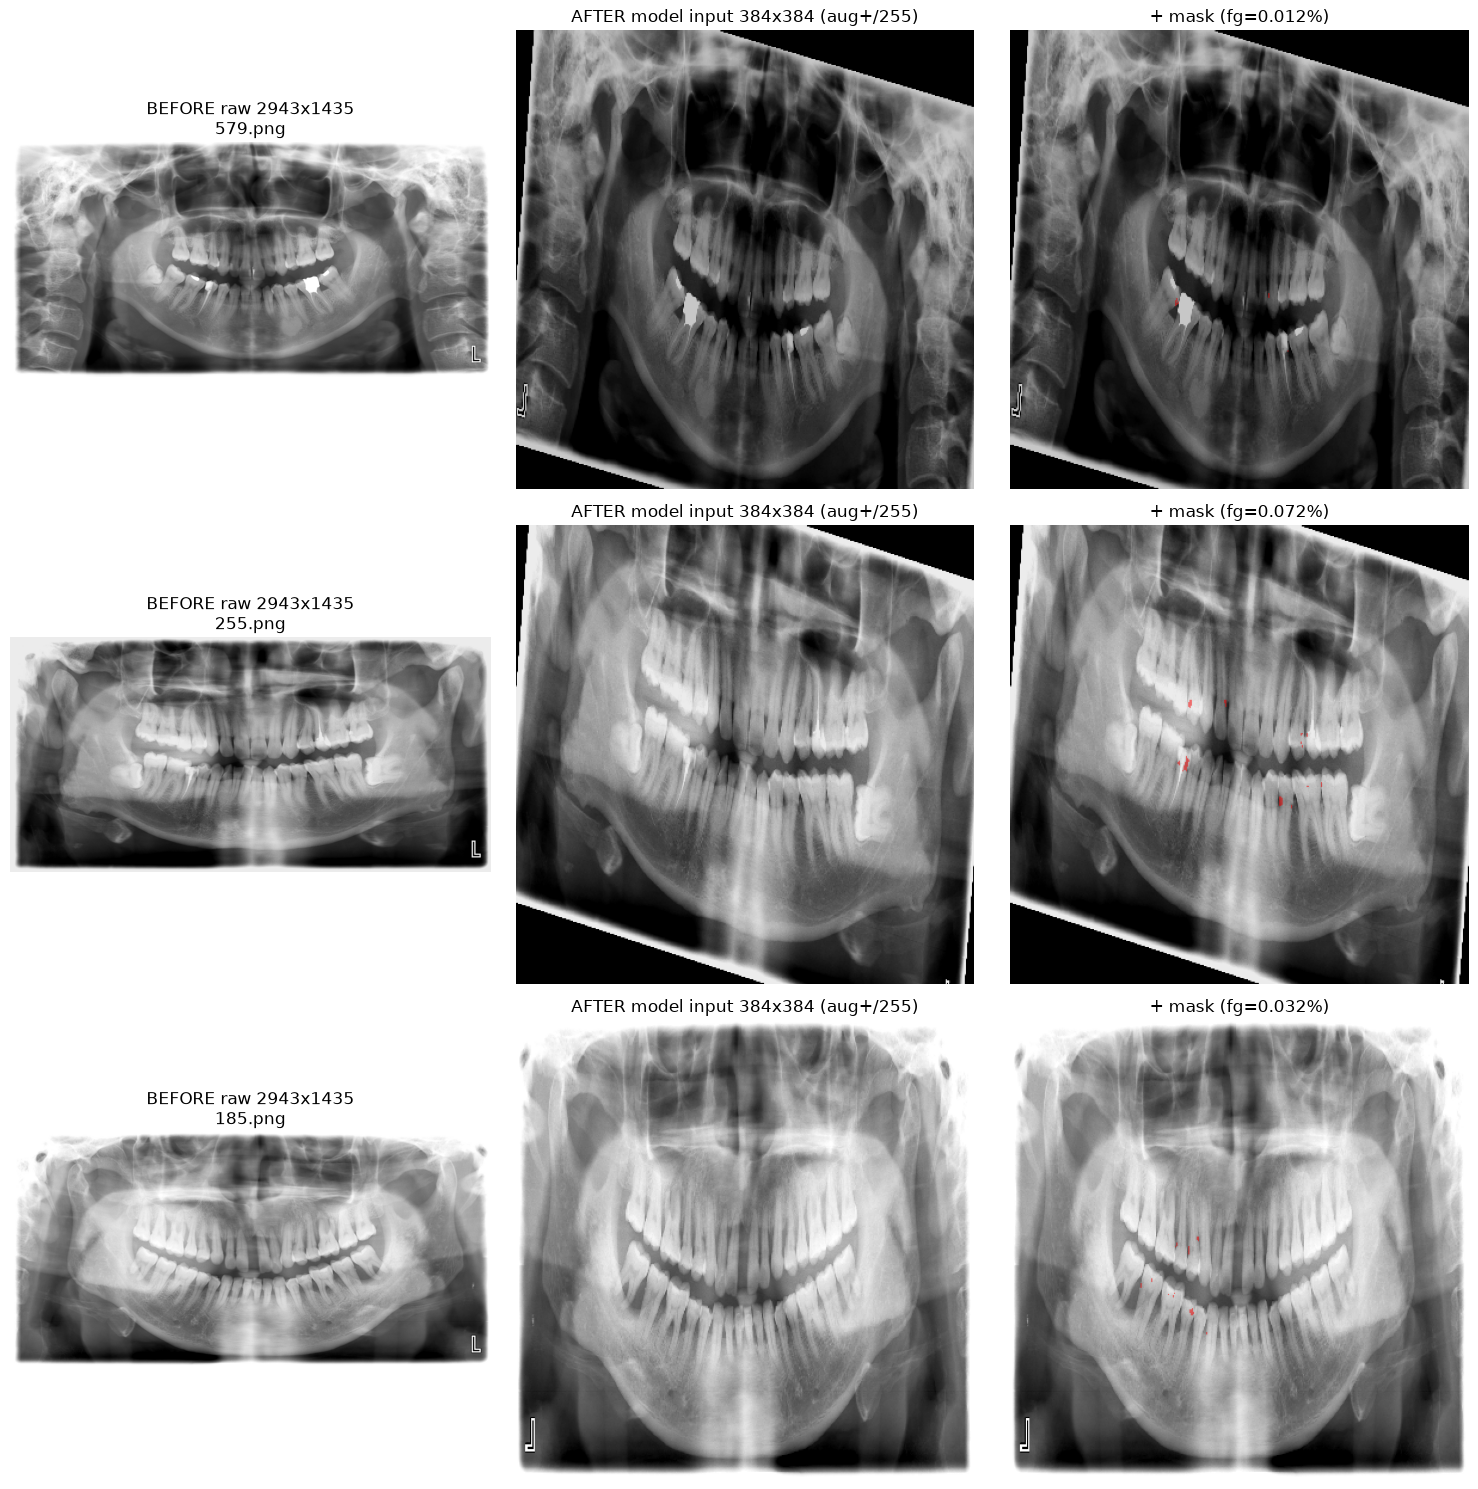

In [9]:
def _denorm(img_chw):  # CHW float [0,1] BGR -> HWC RGB uint8 for display
    im = (np.transpose(img_chw, (1,2,0))*255).astype(np.uint8)
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

_n = 3
fig, ax = plt.subplots(_n, 3, figsize=(15, 5*_n))
for r in range(_n):
    raw = cv2.imread(train_x[r], cv2.IMREAD_COLOR)
    rawm = cv2.imread(train_y[r], cv2.IMREAD_GRAYSCALE)
    img, msk = train_dataset[r]   # goes through aug + resize + /255
    ax[r,0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)); ax[r,0].set_title(f"BEFORE raw {raw.shape[1]}x{raw.shape[0]}\n{os.path.basename(train_x[r])}")
    ax[r,1].imshow(_denorm(img)); ax[r,1].set_title(f"AFTER model input {IMAGE_SIZE}x{IMAGE_SIZE} (aug+/255)")
    disp = _denorm(img); disp[msk[0]>0.5] = (0.5*disp[msk[0]>0.5]+0.5*np.array([255,0,0])).astype(np.uint8)
    ax[r,2].imshow(disp); ax[r,2].set_title(f"+ mask (fg={msk.mean()*100:.3f}%)")
    for c in range(3): ax[r,c].axis("off")
    print(f"[{os.path.basename(train_x[r])}] raw {raw.shape} mask fg={ (rawm>127).mean()*100:.3f}% -> input {img.shape} mask fg={msk.mean()*100:.3f}%")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"preprocess_preview.png"), dpi=110); plt.show()

## 8. Train / evaluate epoch fns — exact repo logic (+ tqdm ETA)

In [10]:
def run_epoch(model, loader, optimizer, device, train_mode, desc):
    model.train() if train_mode else model.eval()
    ep_loss=0.0; ep=[0.0,0.0,0.0,0.0]
    pbar = tqdm(loader, desc=desc, leave=False)
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for i,(x,y) in enumerate(pbar):
            x = x.to(device, dtype=torch.float32); y = y.to(device, dtype=torch.float32)
            if train_mode: optimizer.zero_grad()
            out = model({'images':x,'masks':y}); y_pred = out['prediction']; loss = out['loss']
            if train_mode: loss.backward(); optimizer.step()
            ep_loss += loss.item()
            yp = torch.sigmoid(y_pred)
            bj=[];bf=[];br=[];bp=[]
            for yt,ypp in zip(y,yp):
                s = calculate_metrics(yt,ypp); bj.append(s[0]); bf.append(s[1]); br.append(s[2]); bp.append(s[3])
            ep[0]+=np.mean(bj); ep[1]+=np.mean(bf); ep[2]+=np.mean(br); ep[3]+=np.mean(bp)
            pbar.set_postfix(loss=f"{ep_loss/(i+1):.4f}", dice=f"{ep[1]/(i+1):.4f}")
    n=len(loader)
    return ep_loss/n, [v/n for v in ep]
print("epoch fns ready")

epoch fns ready


## 9. Training loop
Repo recipe (Adam, ReduceLROnPlateau, best-on-val-F1, early stop). **Added:** `best.pth` on best val Dice, per-epoch history → `history.csv`, live per-epoch summary with running best.

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

best_path = os.path.join(OUT_DIR, "best.pth")
hist_path = os.path.join(OUT_DIR, "history.csv")

history=[]; best_valid_f1=0.0; best_epoch=-1; early_stop_count=0

for epoch in range(NUM_EPOCHS):
    t0=time.time()
    tr_loss, tr = run_epoch(model, train_loader, optimizer, DEVICE, True,  f"Epoch {epoch+1}/{NUM_EPOCHS} [train]")
    va_loss, va = run_epoch(model, valid_loader, optimizer, DEVICE, False, f"Epoch {epoch+1}/{NUM_EPOCHS} [val]")
    scheduler.step(va_loss)
    dt=time.time()-t0

    history.append(dict(epoch=epoch+1, train_loss=tr_loss, val_loss=va_loss,
                        train_jac=tr[0], train_dice=tr[1], train_recall=tr[2], train_prec=tr[3],
                        val_jac=va[0], val_dice=va[1], val_recall=va[2], val_prec=va[3],
                        lr=optimizer.param_groups[0]['lr'], sec=dt))
    pd.DataFrame(history).to_csv(hist_path, index=False)

    is_best = va[1] > best_valid_f1
    if is_best:
        best_valid_f1 = va[1]; best_epoch = epoch; early_stop_count = 0
        torch.save(model.state_dict(), best_path)
    else:
        early_stop_count += 1

    flag = "  <-- NEW BEST, saved best.pth" if is_best else ""
    print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | {dt:.0f}s | "
          f"train loss {tr_loss:.4f} dice {tr[1]:.4f} | "
          f"val loss {va_loss:.4f} dice {va[1]:.4f} jac {va[0]:.4f} rec {va[2]:.4f} prec {va[3]:.4f} | "
          f"best dice {best_valid_f1:.4f} (ep {best_epoch+1}){flag}")

    if early_stop_count == EARLY_STOP:
        print(f"Early stopping: val F1 did not improve for {EARLY_STOP} epochs."); break

print(f"\nDONE. Best val Dice = {best_valid_f1:.4f} at epoch {best_epoch+1} -> {best_path}")

Epoch 1/500 [train]:   0%|          | 0/111 [00:00<?, ?it/s]

Epoch 1/500 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 001/500 | 16s | train loss 1.0240 dice 0.0359 | val loss 1.0183 dice 0.0798 jac 0.0454 rec 0.1493 prec 0.0692 | best dice 0.0798 (ep 1)  <-- NEW BEST, saved best.pth


Epoch 2/500 [train]:   0%|          | 0/111 [00:00<?, ?it/s]

Epoch 2/500 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 91/500 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 091/500 | 13s | train loss 0.1949 dice 0.7343 | val loss 0.3741 dice 0.5896 jac 0.4555 rec 0.5476 prec 0.7431 | best dice 0.6061 (ep 42)


Epoch 92/500 [train]:   0%|          | 0/111 [00:00<?, ?it/s]

Epoch 92/500 [val]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 092/500 | 13s | train loss 0.2034 dice 0.7379 | val loss 0.3756 dice 0.5873 jac 0.4541 rec 0.5405 prec 0.7476 | best dice 0.6061 (ep 42)
Early stopping: val F1 did not improve for 50 epochs.

DONE. Best val Dice = 0.6061 at epoch 42 -> output_caries/DoubleUnet/best.pth


## 10. Learning curves

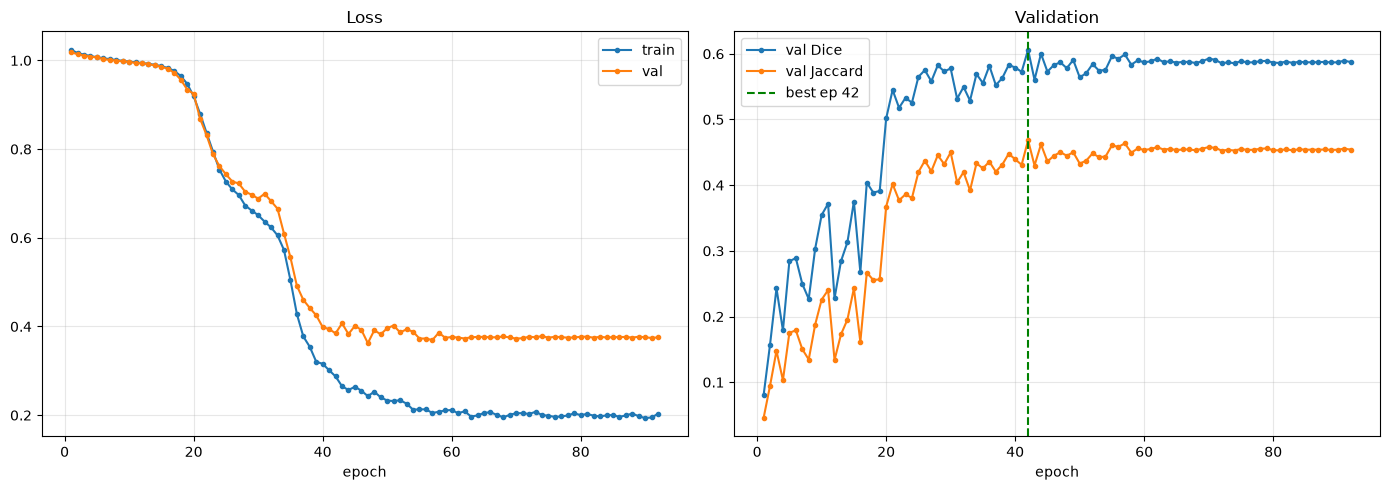

best val Dice: 0.6061337075020425 at epoch 42


In [12]:
H = pd.read_csv(hist_path)
fig,ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(H.epoch,H.train_loss,marker='.',label="train"); ax[0].plot(H.epoch,H.val_loss,marker='.',label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(H.epoch,H.val_dice,marker='.',label="val Dice"); ax[1].plot(H.epoch,H.val_jac,marker='.',label="val Jaccard")
ax[1].axvline(int(H.val_dice.idxmax())+1,ls='--',c='g',label=f"best ep {int(H.val_dice.idxmax())+1}")
ax[1].set_title("Validation"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"learning_curves.png"),dpi=120); plt.show()
print("best val Dice:", float(H.val_dice.max()), "at epoch", int(H.val_dice.idxmax())+1)

## 11. Test evaluation + save predictions — exact copy of `test.py` logic
Loads `best.pth`, evaluates the 100 test panoramics at full resolution, prints Jaccard/Dice/Recall/Precision/Acc/F2/HD + FPS, and saves `pred/` masks + `joint/` (image | GT | pred) triptychs.

In [13]:
def process_mask(y_pred):
    y_pred = y_pred[0].cpu().numpy(); y_pred = np.squeeze(y_pred, axis=0)
    y_pred = (y_pred > 0.5).astype(np.int32) * 255
    y_pred = np.array(y_pred, dtype=np.uint8); y_pred = np.expand_dims(y_pred, axis=-1)
    return np.concatenate([y_pred, y_pred, y_pred], axis=2)

# reload best weights
best_model = DoubleUnet().to(DEVICE)
best_model.load_state_dict(torch.load(best_path, map_location=DEVICE)); best_model.eval()
print("loaded best model")

save_path = os.path.join(OUT_DIR, "result_map")
for item in ["pred","joint"]: os.makedirs(os.path.join(save_path,item), exist_ok=True)

metrics_score=[0.0]*7; time_taken=[]
for x,y in tqdm(list(zip(test_x,test_y)), total=len(test_x), desc="test eval"):
    name = f"test_{os.path.basename(x)}"
    image = cv2.imread(x, cv2.IMREAD_COLOR); save_img = image
    img = cv2.resize(image, SIZE, interpolation=cv2.INTER_NEAREST)
    img = np.expand_dims(np.transpose(img,(2,0,1)),0)/255.0
    img = torch.from_numpy(img.astype(np.float32)).to(DEVICE)

    mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE); save_mask = mask; ori = save_mask.shape
    m = cv2.resize(mask, SIZE, interpolation=cv2.INTER_NEAREST)
    save_mask = np.concatenate([np.expand_dims(save_mask,-1)]*3, axis=2)
    m = np.expand_dims(np.expand_dims(m,0),0); m = (m>127).astype(np.float32)
    m = torch.from_numpy(m).to(DEVICE)

    with torch.no_grad():
        st=time.time()
        out = best_model({'images':img,'masks':m}); yp = torch.sigmoid(out['prediction'])
        time_taken.append(time.time()-st)
        score = calculate_metrics(m, yp); metrics_score = list(map(add, metrics_score, score))
        pred = process_mask(yp)
        pred = cv2.resize(pred, (ori[1],ori[0]), interpolation=cv2.INTER_NEAREST)
    line = np.ones((ori[0],10,3))*255
    cv2.imwrite(os.path.join(save_path,"joint",name), np.concatenate([save_img,line,save_mask,pred],axis=1))
    cv2.imwrite(os.path.join(save_path,"pred",name), pred)

n=len(test_x)
names=["Jaccard","Dice(F1)","Recall","Precision","Acc","F2","HD"]
summary={nm:metrics_score[i]/n for i,nm in enumerate(names)}
summary["FPS"]=1/np.mean(time_taken)
print(" - ".join(f"{k}: {v:.4f}" for k,v in summary.items()))
pd.DataFrame([summary]).to_csv(os.path.join(OUT_DIR,"test_summary.csv"), index=False)

loaded best model


test eval:   0%|          | 0/100 [00:00<?, ?it/s]

[ WARN:0@1215.505] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


Jaccard: 0.5842 - Dice(F1): 0.7216 - Recall: 0.7141 - Precision: 0.7704 - Acc: 0.9994 - F2: 0.7142 - HD: 2.0566 - FPS: 184.7598


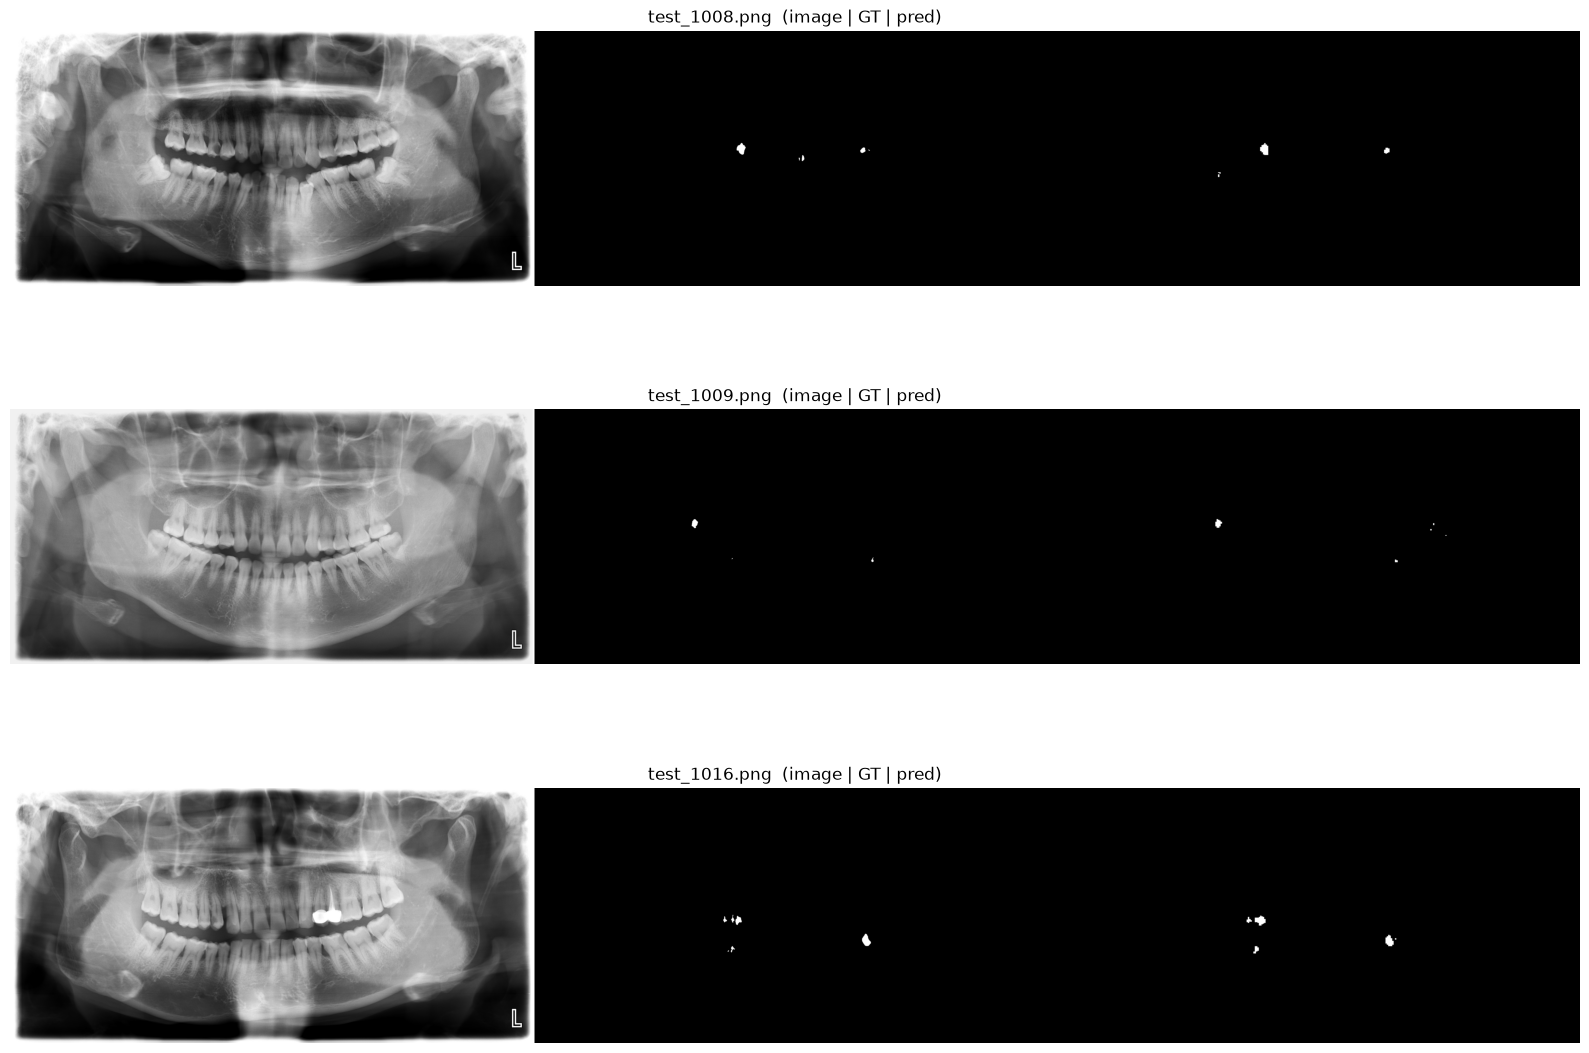

In [14]:
# preview a few saved triptychs (image | GT | pred)
import matplotlib.image as mpimg
joints = sorted(_glob(os.path.join(save_path,"joint","*.png")))[:3]
fig,axes=plt.subplots(len(joints),1,figsize=(16,4*len(joints)))
if len(joints)==1: axes=[axes]
for ax,jp in zip(axes,joints):
    ax.imshow(cv2.cvtColor(cv2.imread(jp),cv2.COLOR_BGR2RGB)); ax.set_title(os.path.basename(jp)+"  (image | GT | pred)"); ax.axis("off")
plt.tight_layout(); plt.show()

## Outputs (under `output_caries/DoubleUnet/`)
- `best.pth` — best **val Dice** weights (matches repo's `checkpoint.pth` selection)
- `history.csv`, `learning_curves.png`, `preprocess_preview.png`
- `test_summary.csv` — Jaccard/Dice/Recall/Precision/Acc/F2/HD + FPS
- `result_map/pred/*` and `result_map/joint/*` — predicted masks and image|GT|pred triptychs

(The dataset is downloaded once to `output_caries/data/`.)

### Notes
- This is the repo recipe unchanged. Expect ~0.73 Dice (paper's reported DoubleU-Net result).
- 500 epochs is the repo default; early stopping (patience 50) typically ends much earlier.
  Lower `NUM_EPOCHS` to smoke-test the full pipeline quickly.